In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [ ]:
data = pd.read_csv("cafe_sales.csv")
data.head()

,transaction_id,transaction_date,transaction_time,sales_outlet_id,staff_id,customer_id,instore_yn,order,line_item_id,product_id,...,product_category,product_type,product,product_description,unit_of_measure,current_wholesale_price,current_retail_price,tax_exempt_yn,promo_yn,new_product_yn
0,7,2019-04-01,12:04:43,3,12,558,N,1,1,52,...,Tea,Brewed Chai tea,Traditional Blend Chai Rg,Sit back and think of the tropical breezes.,16 oz,0.63,$2.50,Y,N,N
1,11,2019-04-01,15:54:39,3,17,781,N,1,1,27,...,Coffee,Organic brewed coffee,Brazilian Lg,It's like Carnival in a cup. Clean and smooth.,24 oz,0.70,$3.50,Y,N,N
2,19,2019-04-01,14:34:59,3,17,788,Y,1,1,46,...,Tea,Brewed Green tea,Serenity Green Tea Rg,Feel the stress leaving your body.,16 oz,0.63,$2.50,Y,N,N
3,32,2019-04-01,16:06:04,3,12,683,N,1,1,23,...,Coffee,Drip coffee,Our Old Time Diner Blend Rg,An honest cup a coffee.,16 oz,0.50,$2.50,Y,N,N
4,33,2019-04-01,19:18:37,3,17,99,Y,1,1,34,...,Coffee,Premium brewed coffee,Jamaican Coffee River Sm,Still a front runner for good premium coffee.,8 oz,0.49,$2.45,Y,N,N


Karena terdapat 49 feature jadi sebaiknya di drop untuk kolom yang tidak diperlukan untuk analisis

In [ ]:
# Tentukan kolom yang akan dihapus
columns_to_drop = [
    'instore_yn', 'staff_id',
    'promo_item_yn', 'line_item_id', 'product_id', 'product_description',
    'unit_of_measure', 'current_wholesale_price', 'tax_exempt_yn',
    'promo_yn', 'new_product_yn','home_store', 'position','location', 'sales_outlet_type',
    'store_square_feet', 'store_address', 'store_telephone', 'store_postal_code', 'store_longitude',
    'store_latitude', 'manager', 'Neighorhood','current_retail_price', 'store_city', 'store_state_province',
    'birth_year'

]

# Hapus kolom yang tidak relevan
data2 = data.drop(columns=columns_to_drop)

# Tampilkan beberapa baris pertama dari data yang telah dibersihkan
data2.head()

,transaction_id,transaction_date,transaction_time,sales_outlet_id,customer_id,order,quantity,line_item_amount,unit_price,customer_first-name,...,loyalty_card_number,birthdate,gender,first_name,last_name,start_date,product_group,product_category,product_type,product
0,7,2019-04-01,12:04:43,3,558,1,1,2.50,2.50,Melissa Johnson,...,816-924-9433,1983-02-25,F,Britanni,Jorden,3/25/2006,Beverages,Tea,Brewed Chai tea,Traditional Blend Chai Rg
1,11,2019-04-01,15:54:39,3,781,1,2,7.00,3.50,Luke Patel,...,653-218-9979,1991-07-29,N,Quail,Octavia,12/5/2014,Beverages,Coffee,Organic brewed coffee,Brazilian Lg
2,19,2019-04-01,14:34:59,3,788,1,2,5.00,2.50,Hilel Ballard,...,263-826-9026,1995-02-23,N,Quail,Octavia,12/5/2014,Beverages,Tea,Brewed Green tea,Serenity Green Tea Rg
3,32,2019-04-01,16:06:04,3,683,1,2,5.00,2.50,Zephr Zimmerman,...,741-320-7166,1999-02-06,F,Britanni,Jorden,3/25/2006,Beverages,Coffee,Drip coffee,Our Old Time Diner Blend Rg
4,33,2019-04-01,19:18:37,3,99,1,1,2.45,2.45,Orlando Shields,...,747-164-4596,1967-01-29,M,Quail,Octavia,12/5/2014,Beverages,Coffee,Premium brewed coffee,Jamaican Coffee River Sm


In [ ]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49894 entries, 0 to 49893
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       49894 non-null  int64  
 1   transaction_date     49894 non-null  object 
 2   transaction_time     49894 non-null  object 
 3   sales_outlet_id      49894 non-null  int64  
 4   customer_id          49894 non-null  int64  
 5   order                49894 non-null  int64  
 6   quantity             49894 non-null  int64  
 7   line_item_amount     49894 non-null  float64
 8   unit_price           49894 non-null  float64
 9   customer_first-name  24852 non-null  object 
 10  customer_email       24852 non-null  object 
 11  customer_since       24852 non-null  object 
 12  loyalty_card_number  24852 non-null  object 
 13  birthdate            24852 non-null  object 
 14  gender               24852 non-null  object 
 15  first_name           49894 non-null 

In [ ]:
data2.describe()

,transaction_id,sales_outlet_id,customer_id,order,quantity,line_item_amount,unit_price
count,49894.000000,49894.000000,49894.000000,49894.000000,49894.000000,49894.000000,49894.000000
mean,869.056059,5.351846,2282.324468,1.173428,1.438209,4.682646,3.384645
std,857.863149,2.074796,3240.551757,1.025445,0.543039,4.436668,2.682545
min,1.000000,3.000000,0.000000,1.000000,1.000000,0.000000,0.800000
25%,223.000000,3.000000,0.000000,1.000000,1.000000,3.000000,2.500000
50%,481.000000,5.000000,0.000000,1.000000,1.000000,3.750000,3.000000
75%,1401.000000,8.000000,5412.000000,1.000000,2.000000,6.000000,3.750000
max,4203.000000,8.000000,8501.000000,9.000000,8.000000,360.000000,45.000000


##Feature Enginering

In [ ]:
#checking duplicate
len(data2.drop_duplicates()) / len(data2)

0.9983565158135247

In [ ]:
# Menghapus baris yang duplikat di seluruh dataset
data_cleaned = data2.drop_duplicates()

# Menampilkan beberapa baris pertama dari data yang sudah dibersihkan
data_cleaned.head()

,transaction_id,transaction_date,transaction_time,sales_outlet_id,customer_id,order,quantity,line_item_amount,unit_price,customer_first-name,...,loyalty_card_number,birthdate,gender,first_name,last_name,start_date,product_group,product_category,product_type,product
0,7,2019-04-01,12:04:43,3,558,1,1,2.50,2.50,Melissa Johnson,...,816-924-9433,1983-02-25,F,Britanni,Jorden,3/25/2006,Beverages,Tea,Brewed Chai tea,Traditional Blend Chai Rg
1,11,2019-04-01,15:54:39,3,781,1,2,7.00,3.50,Luke Patel,...,653-218-9979,1991-07-29,N,Quail,Octavia,12/5/2014,Beverages,Coffee,Organic brewed coffee,Brazilian Lg
2,19,2019-04-01,14:34:59,3,788,1,2,5.00,2.50,Hilel Ballard,...,263-826-9026,1995-02-23,N,Quail,Octavia,12/5/2014,Beverages,Tea,Brewed Green tea,Serenity Green Tea Rg
3,32,2019-04-01,16:06:04,3,683,1,2,5.00,2.50,Zephr Zimmerman,...,741-320-7166,1999-02-06,F,Britanni,Jorden,3/25/2006,Beverages,Coffee,Drip coffee,Our Old Time Diner Blend Rg
4,33,2019-04-01,19:18:37,3,99,1,1,2.45,2.45,Orlando Shields,...,747-164-4596,1967-01-29,M,Quail,Octavia,12/5/2014,Beverages,Coffee,Premium brewed coffee,Jamaican Coffee River Sm


In [ ]:
#checking duplicate
len(data_cleaned.drop_duplicates()) / len(data_cleaned)

1.0

In [ ]:
# Identifying Missing value
data2.isna().sum()

,0
transaction_id,0
transaction_date,0
transaction_time,0
sales_outlet_id,0
customer_id,0
order,0
quantity,0
line_item_amount,0
unit_price,0
customer_first-name,25042


In [ ]:
# Check Missing Value
# percentage version
total_rows = len(data_cleaned)

# Menghitung dan menampilkan persentase missing values di setiap kolom satu per satu
for column in data_cleaned.columns:
    missing_count = data2[column].isna().sum()
    missing_percentage = (missing_count / total_rows) * 100
    print(f"Column '{column}' Has {missing_count} missing values ({missing_percentage:.2f}%)") # .2f means 2 decimal

Column 'transaction_id' Has 0 missing values (0.00%)
Column 'transaction_date' Has 0 missing values (0.00%)
Column 'transaction_time' Has 0 missing values (0.00%)
Column 'sales_outlet_id' Has 0 missing values (0.00%)
Column 'customer_id' Has 0 missing values (0.00%)
Column 'order' Has 0 missing values (0.00%)
Column 'quantity' Has 0 missing values (0.00%)
Column 'line_item_amount' Has 0 missing values (0.00%)
Column 'unit_price' Has 0 missing values (0.00%)
Column 'customer_first-name' Has 25042 missing values (50.27%)
Column 'customer_email' Has 25042 missing values (50.27%)
Column 'customer_since' Has 25042 missing values (50.27%)
Column 'loyalty_card_number' Has 25042 missing values (50.27%)
Column 'birthdate' Has 25042 missing values (50.27%)
Column 'gender' Has 25042 missing values (50.27%)
Column 'first_name' Has 0 missing values (0.00%)
Column 'last_name' Has 0 missing values (0.00%)
Column 'start_date' Has 0 missing values (0.00%)
Column 'product_group' Has 0 missing values (0.

In [ ]:
# Menampilkan baris yang memiliki nilai null di seluruh dataset
data_with_nulls = data_cleaned[data.isnull().any(axis=1)]

# Menampilkan beberapa baris pertama dari data dengan nilai null
data_with_nulls.head()

<ipython-input-11-cac7c66b3a86>:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_with_nulls = data_cleaned[data.isnull().any(axis=1)]


,transaction_id,transaction_date,transaction_time,sales_outlet_id,customer_id,order,quantity,line_item_amount,unit_price,customer_first-name,...,loyalty_card_number,birthdate,gender,first_name,last_name,start_date,product_group,product_category,product_type,product
3854,2356,2019-04-03,11:46:54,3,0,1,1,2.0,2.00,NaN,...,NaN,NaN,NaN,Britanni,Jorden,3/25/2006,Beverages,Coffee,Drip coffee,Our Old Time Diner Blend Sm
3855,2356,2019-04-03,11:46:54,3,0,1,1,3.0,3.00,NaN,...,NaN,NaN,NaN,Britanni,Jorden,3/25/2006,Food,Bakery,Scone,Oatmeal Scone
5509,2337,2019-04-04,16:20:11,3,0,1,2,8.0,4.00,NaN,...,NaN,NaN,NaN,Quail,Octavia,12/5/2014,Beverages,Tea,Brewed Chai tea,Morning Sunrise Chai Lg
9002,1826,2019-04-06,13:42:01,5,5000,1,2,7.5,3.75,NaN,...,NaN,NaN,NaN,Joelle,Christen,11/11/2013,Beverages,Drinking Chocolate,Hot chocolate,Sustainably Grown Organic Rg
10191,4,2019-04-07,10:26:52,5,0,1,1,3.5,3.50,NaN,...,NaN,NaN,NaN,Orson,Benedict,7/26/2016,Beverages,Coffee,Gourmet brewed coffee,Ethiopia Lg


In [ ]:
# Menghapus baris yang memiliki nilai null di seluruh dataset
data_cleaned = data_cleaned.dropna()

# Menampilkan beberapa baris pertama dari data yang sudah dibersihkan
data_cleaned.head()

,transaction_id,transaction_date,transaction_time,sales_outlet_id,customer_id,order,quantity,line_item_amount,unit_price,customer_first-name,...,loyalty_card_number,birthdate,gender,first_name,last_name,start_date,product_group,product_category,product_type,product
0,7,2019-04-01,12:04:43,3,558,1,1,2.50,2.50,Melissa Johnson,...,816-924-9433,1983-02-25,F,Britanni,Jorden,3/25/2006,Beverages,Tea,Brewed Chai tea,Traditional Blend Chai Rg
1,11,2019-04-01,15:54:39,3,781,1,2,7.00,3.50,Luke Patel,...,653-218-9979,1991-07-29,N,Quail,Octavia,12/5/2014,Beverages,Coffee,Organic brewed coffee,Brazilian Lg
2,19,2019-04-01,14:34:59,3,788,1,2,5.00,2.50,Hilel Ballard,...,263-826-9026,1995-02-23,N,Quail,Octavia,12/5/2014,Beverages,Tea,Brewed Green tea,Serenity Green Tea Rg
3,32,2019-04-01,16:06:04,3,683,1,2,5.00,2.50,Zephr Zimmerman,...,741-320-7166,1999-02-06,F,Britanni,Jorden,3/25/2006,Beverages,Coffee,Drip coffee,Our Old Time Diner Blend Rg
4,33,2019-04-01,19:18:37,3,99,1,1,2.45,2.45,Orlando Shields,...,747-164-4596,1967-01-29,M,Quail,Octavia,12/5/2014,Beverages,Coffee,Premium brewed coffee,Jamaican Coffee River Sm


In [ ]:
data_cleaned.shape

(24826, 22)

In [ ]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24826 entries, 0 to 49893
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       24826 non-null  int64  
 1   transaction_date     24826 non-null  object 
 2   transaction_time     24826 non-null  object 
 3   sales_outlet_id      24826 non-null  int64  
 4   customer_id          24826 non-null  int64  
 5   order                24826 non-null  int64  
 6   quantity             24826 non-null  int64  
 7   line_item_amount     24826 non-null  float64
 8   unit_price           24826 non-null  float64
 9   customer_first-name  24826 non-null  object 
 10  customer_email       24826 non-null  object 
 11  customer_since       24826 non-null  object 
 12  loyalty_card_number  24826 non-null  object 
 13  birthdate            24826 non-null  object 
 14  gender               24826 non-null  object 
 15  first_name           24826 non-null  obje

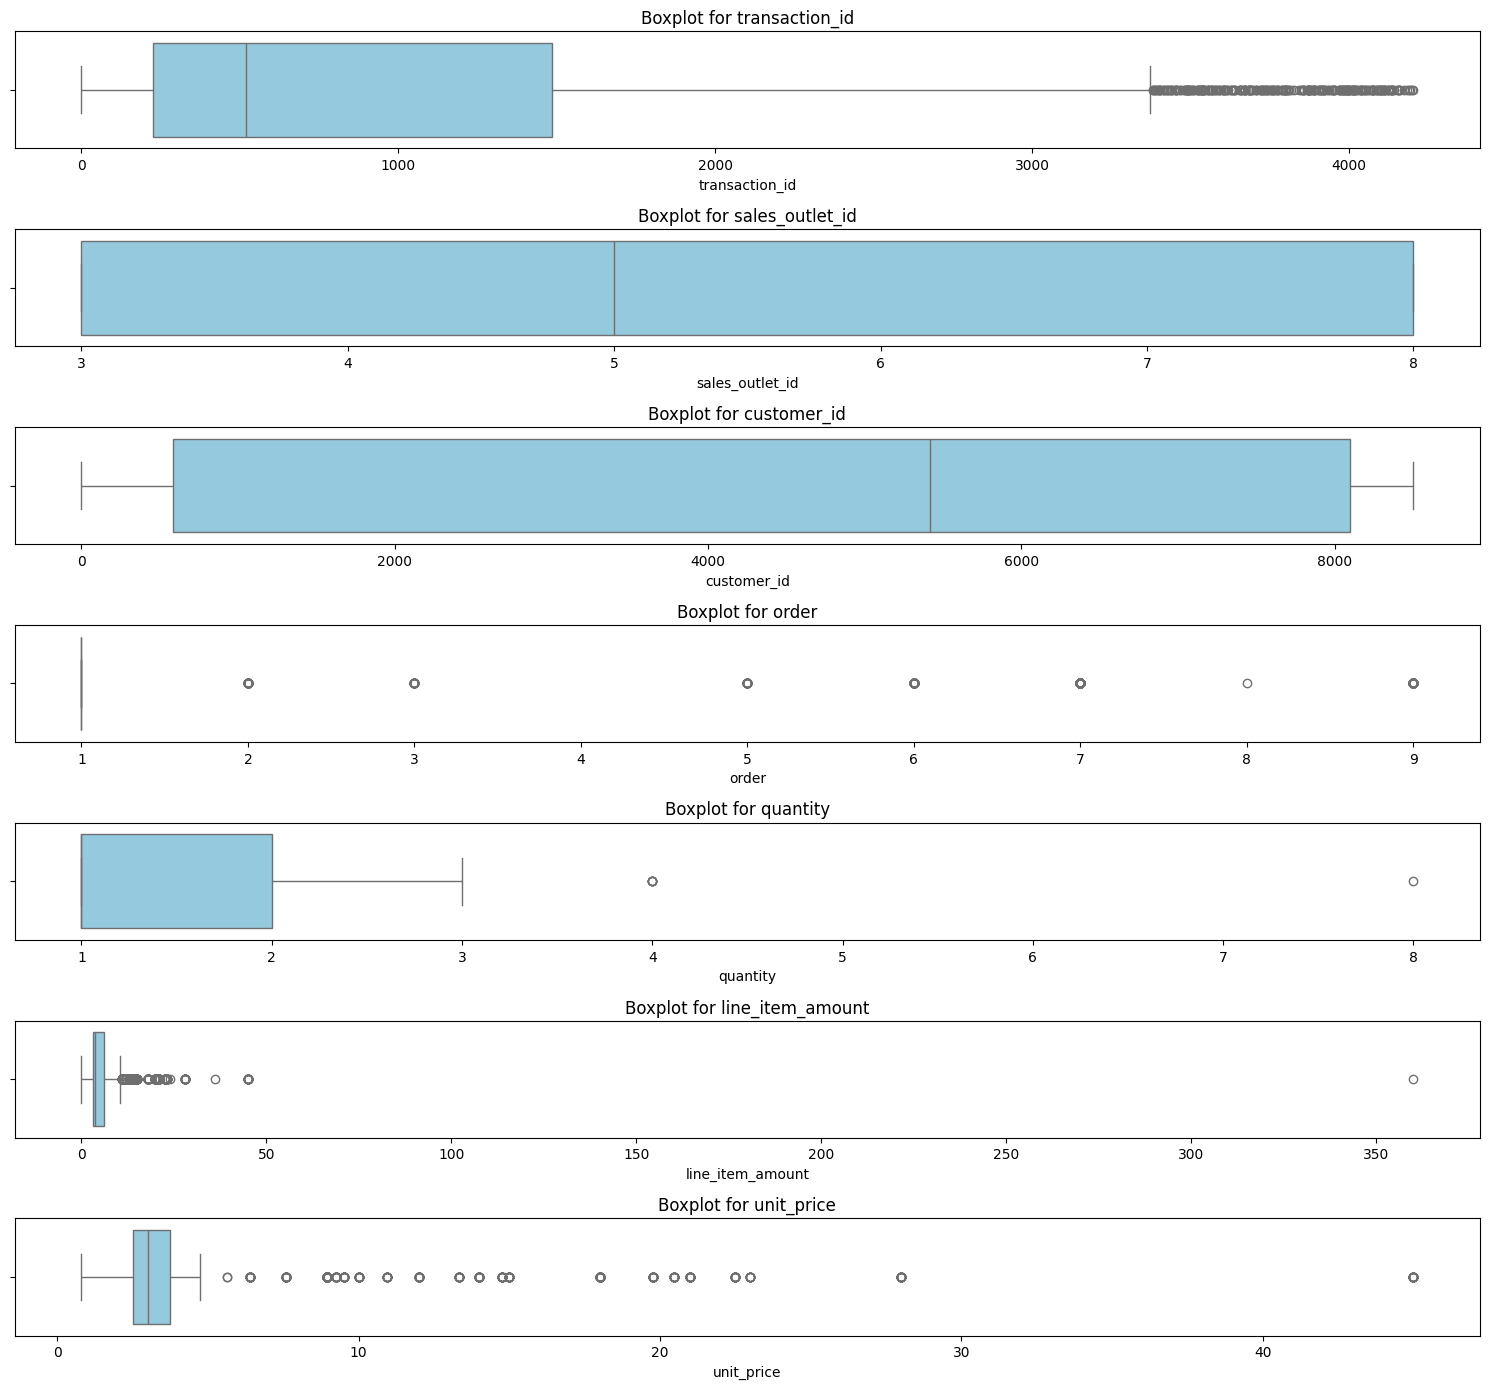

In [ ]:
# Memfilter kolom numerik
numeric_columns = data_cleaned.select_dtypes(include='number').columns

# Membuat boxplot untuk setiap kolom numerik
plt.figure(figsize=(15, len(numeric_columns) * 2))  # Menyesuaikan ukuran plot
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(len(numeric_columns), 1, i)
    sns.boxplot(data=data_cleaned, x=column, color="skyblue")
    plt.title(f'Boxplot for {column}')
    plt.xlabel(column)

plt.tight_layout()
plt.show()

In [ ]:
# Menghitung IQR untuk kolom tertentu
Q1 = data_cleaned['line_item_amount'].quantile(0.25)
Q3 = data_cleaned['line_item_amount'].quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas bawah dan atas untuk mengidentifikasi outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Menghapus outliers yang berada di luar batas
data_cleaned_no_outliers = data_cleaned[(data_cleaned['line_item_amount'] >= lower_bound) &
                                         (data_cleaned['line_item_amount'] <= upper_bound)]

# Menampilkan data setelah menghapus outliers
data_cleaned_no_outliers.head()

,transaction_id,transaction_date,transaction_time,sales_outlet_id,customer_id,order,quantity,line_item_amount,unit_price,customer_first-name,...,loyalty_card_number,birthdate,gender,first_name,last_name,start_date,product_group,product_category,product_type,product
0,7,2019-04-01,12:04:43,3,558,1,1,2.50,2.50,Melissa Johnson,...,816-924-9433,1983-02-25,F,Britanni,Jorden,3/25/2006,Beverages,Tea,Brewed Chai tea,Traditional Blend Chai Rg
1,11,2019-04-01,15:54:39,3,781,1,2,7.00,3.50,Luke Patel,...,653-218-9979,1991-07-29,N,Quail,Octavia,12/5/2014,Beverages,Coffee,Organic brewed coffee,Brazilian Lg
2,19,2019-04-01,14:34:59,3,788,1,2,5.00,2.50,Hilel Ballard,...,263-826-9026,1995-02-23,N,Quail,Octavia,12/5/2014,Beverages,Tea,Brewed Green tea,Serenity Green Tea Rg
3,32,2019-04-01,16:06:04,3,683,1,2,5.00,2.50,Zephr Zimmerman,...,741-320-7166,1999-02-06,F,Britanni,Jorden,3/25/2006,Beverages,Coffee,Drip coffee,Our Old Time Diner Blend Rg
4,33,2019-04-01,19:18:37,3,99,1,1,2.45,2.45,Orlando Shields,...,747-164-4596,1967-01-29,M,Quail,Octavia,12/5/2014,Beverages,Coffee,Premium brewed coffee,Jamaican Coffee River Sm


##EDA

Dayapart, CLV

### Daypart Analysis

In [ ]:
# Convert transaction_time to datetime format
data_cleaned['transaction_time'] = pd.to_datetime(data_cleaned['transaction_time'], format='%H:%M:%S').dt.time

# Define a function to categorize dayparts based on the transaction time
def categorize_daypart(time):
    if time >= pd.to_datetime('06:00:00').time() and time < pd.to_datetime('12:00:00').time():
        return 'Morning'
    elif time >= pd.to_datetime('12:00:00').time() and time < pd.to_datetime('14:00:00').time():
        return 'Noon'
    elif time >= pd.to_datetime('14:00:00').time() and time < pd.to_datetime('18:00:00').time():
        return 'Afternoon'
    elif time >= pd.to_datetime('18:00:00').time() and time < pd.to_datetime('22:00:00').time():
        return 'Evening'
    else:
        return 'Night'

# Apply the function to create a new 'daypart' column
data_cleaned['daypart'] = data_cleaned['transaction_time'].apply(categorize_daypart)

# Now let's check the distribution of transactions across different dayparts
daypart_summary = data_cleaned['daypart'].value_counts().sort_index()

# Display the summary
daypart_summary

,count
daypart,
Afternoon,6941
Evening,2733
Morning,11700
Noon,3452


Morning: 06:00 AM to 11:59 AM

Noon: 12:00 PM to 01:59 PM

Afternoon: 02:00 PM to 05:59 PM

Evening: 06:00 PM to 09:59 PM

Night: 10:00 PM to 05:59 AM

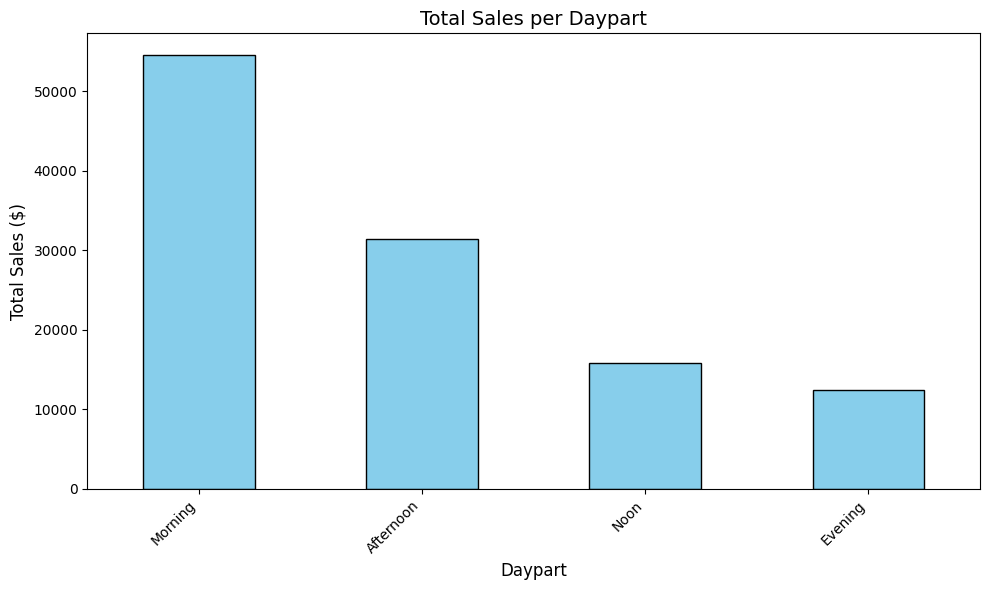

In [ ]:
# Ensure the 'line_item_amount' column is numeric
data_cleaned['line_item_amount'] = pd.to_numeric(data_cleaned['line_item_amount'], errors='coerce')

# Group by daypart and sum the 'line_item_amount' for total sales per daypart
sales_per_daypart = data_cleaned.groupby('daypart')['line_item_amount'].sum().sort_values(ascending=False)

# Plot the total sales per daypart
plt.figure(figsize=(10, 6))
sales_per_daypart.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Sales per Daypart', fontsize=14)
plt.xlabel('Daypart', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

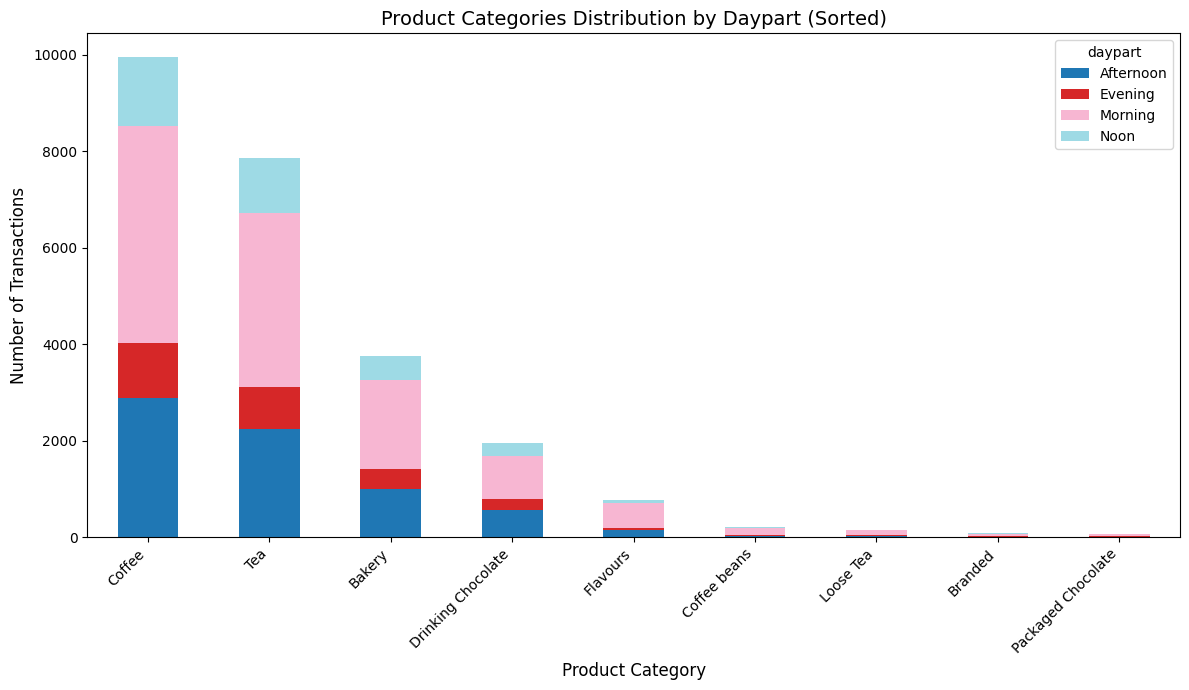

In [ ]:
category_daypart_summary = data_cleaned.groupby(['product_category', 'daypart']).size().unstack()

# Sort the product categories by the total number of transactions across all dayparts
category_daypart_summary_sorted = category_daypart_summary.sum(axis=1).sort_values(ascending=False)

# Reorder the original dataframe based on the sorted product categories
category_daypart_summary_sorted = category_daypart_summary.loc[category_daypart_summary_sorted.index]

# Plot the distribution of product categories based on daypart with sorted order
category_daypart_summary_sorted.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')
plt.title('Product Categories Distribution by Daypart (Sorted)', fontsize=14)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

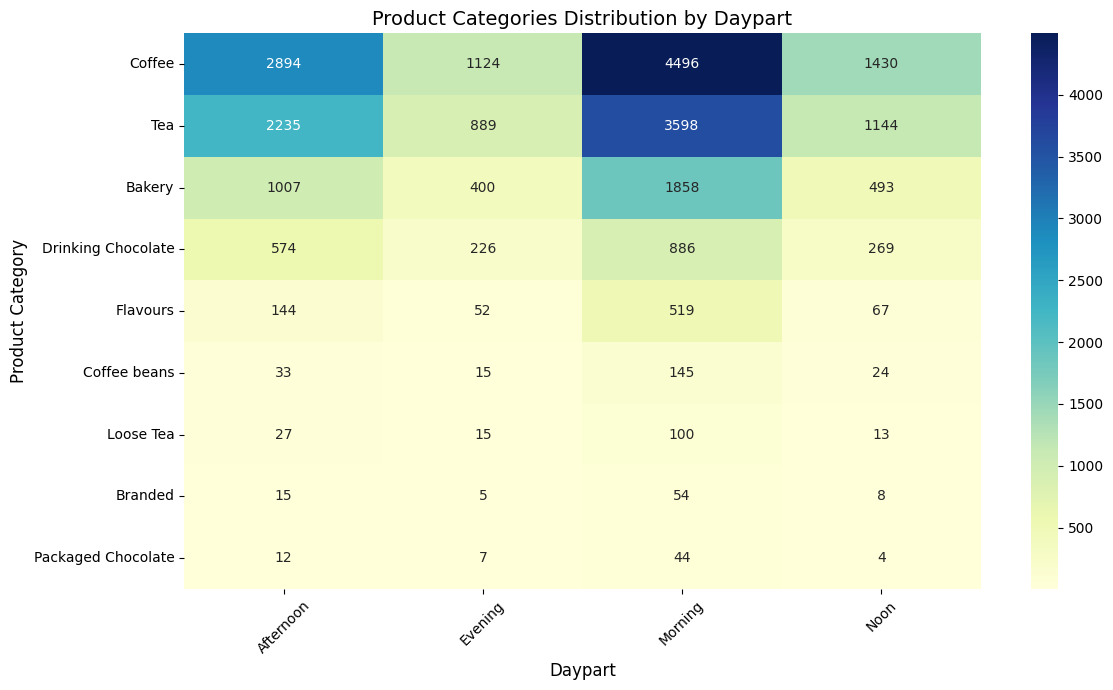

In [ ]:

# Create a heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(category_daypart_summary_sorted, annot=True, cmap='YlGnBu', fmt='g')
plt.title('Product Categories Distribution by Daypart', fontsize=14)
plt.xlabel('Daypart', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### CLV

In [ ]:
!pip install lifetimes

In [ ]:
from lifetimes import GammaGammaFitter
from lifetimes import BetaGeoFitter
from lifetimes.plotting import plot_frequency_recency_matrix
from lifetimes.utils import summary_data_from_transaction_data

# create summary data from transaction data
summary = summary_data_from_transaction_data(data_cleaned,
                                             customer_id_col = 'customer_id',
                                             datetime_col = 'transaction_date',
                                             monetary_value_col='line_item_amount',
                                             observation_period_end = max(data_cleaned["transaction_date"]))

summary = summary[summary["monetary_value"] > 0]

# Merge 'sales_outlet_id' from 'data_cleaned' into 'summary'
# Assuming 'customer_id' is the common column
summary = summary.merge(data_cleaned[['customer_id', 'sales_outlet_id']].drop_duplicates(), on='customer_id', how='left')


# fit the BG/NBD model
bgf = BetaGeoFitter(penalizer_coef=0.1) # Increased penalizer_coef
bgf.fit(summary['frequency'], summary['recency'], summary['T'])

# fit the Gamma-Gamma submodel
ggf = GammaGammaFitter(penalizer_coef=0.0)
ggf.fit(summary['frequency'], summary['monetary_value'])


# predict customer lifetime value
summary['predicted_purchases'] = bgf.predict(30, summary['frequency'], summary['recency'], summary['T'])
summary['predicted_clv'] = ggf.customer_lifetime_value(bgf,
                                                       summary['frequency'],
                                                       summary['recency'],
                                                       summary['T'],
                                                       summary['monetary_value'],
                                                       time=1, #the lifetime expected for the user in months
                                                       freq='D',
                                                       discount_rate=0.01)
summary["estimated_monetary_value"] = ggf.conditional_expected_average_profit(
        summary['frequency'],
        summary['monetary_value']
    )

summary.head()

,customer_id,frequency,recency,T,monetary_value,sales_outlet_id,predicted_purchases,predicted_clv,estimated_monetary_value
0,1,5.0,27.0,27.0,5.240000,3,5.826192,34.602047,5.998441
1,2,11.0,25.0,28.0,6.895455,3,10.993019,75.179502,6.907229
2,3,10.0,23.0,28.0,18.450000,3,10.103075,151.481038,15.143493
3,4,4.0,24.0,27.0,6.562500,3,4.909042,32.815939,6.751643
4,5,5.0,28.0,28.0,4.100000,3,5.653359,30.042468,5.367232


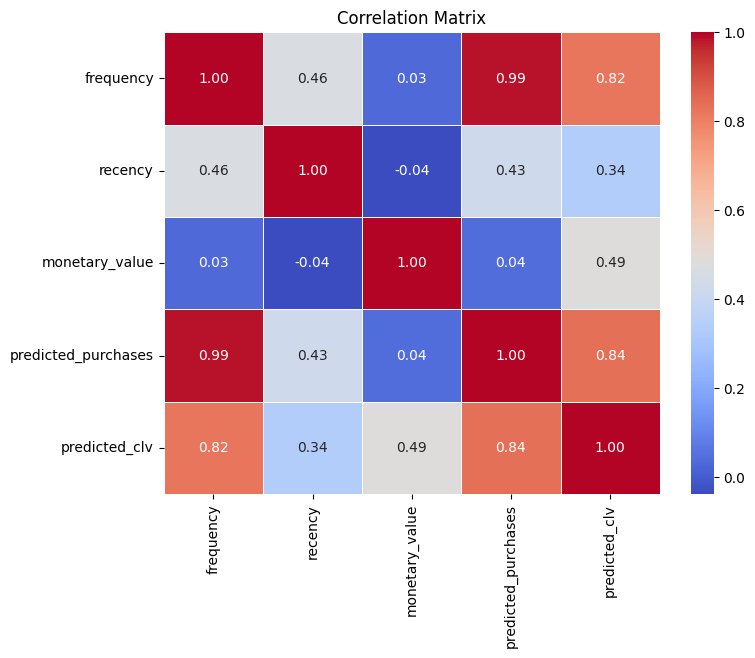

In [ ]:
# Menghitung korelasi antar fitur
correlation_matrix = summary[['frequency', 'recency', 'monetary_value', 'predicted_purchases', 'predicted_clv']].corr()

# Visualisasi korelasi dengan heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

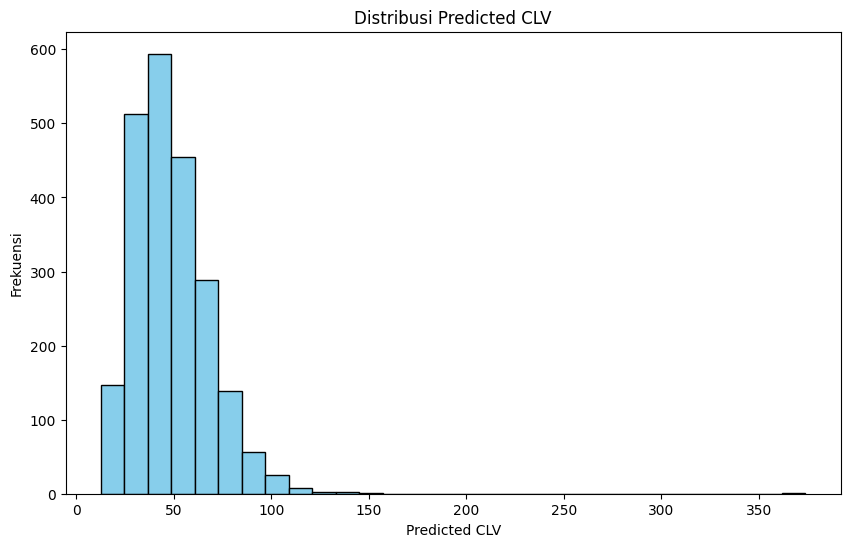

In [ ]:
# Plot distribusi predicted CLV
plt.figure(figsize=(10,6))
plt.hist(summary['predicted_clv'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribusi Predicted CLV')
plt.xlabel('Predicted CLV')
plt.ylabel('Frekuensi')
plt.show()

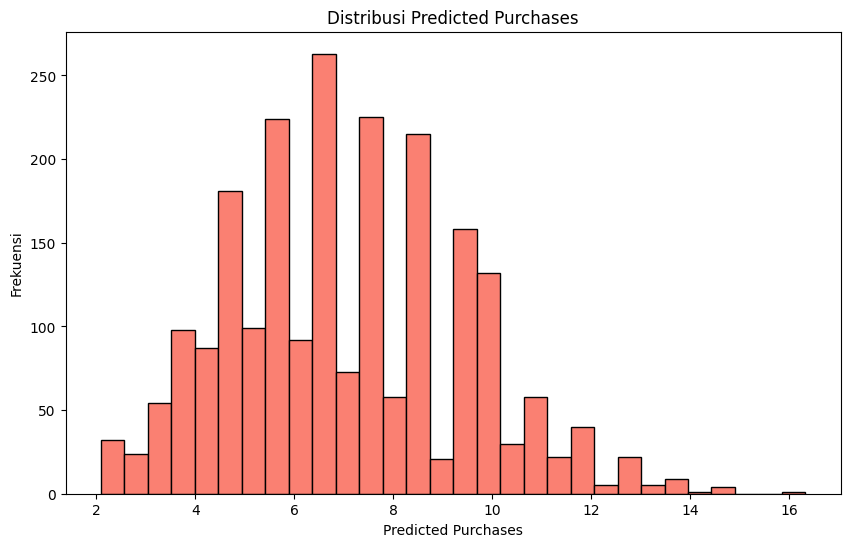

In [ ]:
# Plot distribusi predicted purchases
plt.figure(figsize=(10,6))
plt.hist(summary['predicted_purchases'], bins=30, color='salmon', edgecolor='black')
plt.title('Distribusi Predicted Purchases')
plt.xlabel('Predicted Purchases')
plt.ylabel('Frekuensi')
plt.show()

In [ ]:
# Menghitung total CLV per sales_outlet_id
total_clv_per_outlet = summary.groupby('sales_outlet_id')['predicted_clv'].sum().reset_index()

# Menampilkan hasil
print(total_clv_per_outlet)

   sales_outlet_id  predicted_clv
0                3   37252.894050
1                5   39199.622342
2                8   32354.760741


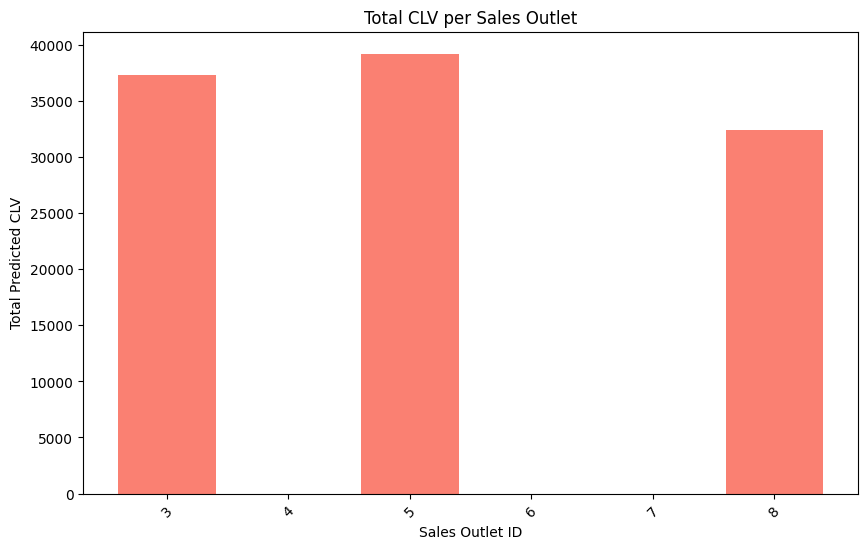

In [ ]:
# Bar plot untuk total CLV per outlet
plt.figure(figsize=(10,6))
plt.bar(total_clv_per_outlet['sales_outlet_id'], total_clv_per_outlet['predicted_clv'], color='salmon')
plt.title('Total CLV per Sales Outlet')
plt.xlabel('Sales Outlet ID')
plt.ylabel('Total Predicted CLV')
plt.xticks(rotation=45)
plt.show()

###customer segmentation dengan RFM

In [ ]:
# Tentukan kuantil untuk masing-masing RFM
rfm = summary[['customer_id', 'recency', 'frequency', 'monetary_value']]

# Mendefinisikan batas kuantil untuk Recency
rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1])

# Mendefinisikan batas kuantil untuk Frequency
rfm['F_score'] = pd.qcut(rfm['frequency'], 5, labels=[1, 2, 3, 4, 5])

# Mendefinisikan batas kuantil untuk Monetary
rfm['M_score'] = pd.qcut(rfm['monetary_value'], 5, labels=[1, 2, 3, 4, 5])

# Menambahkan skor RFM ke dalam summary
summary = summary.merge(rfm[['customer_id', 'R_score', 'F_score', 'M_score']], on='customer_id')

# Menggabungkan skor untuk mendapatkan total RFM Score
summary['RFM_score'] = summary['R_score'].astype(str) + summary['F_score'].astype(str) + summary['M_score'].astype(str)

# Menampilkan beberapa baris hasilnya
summary[['customer_id', 'R_score', 'F_score', 'M_score', 'RFM_score']].head()

,customer_id,R_score,F_score,M_score,RFM_score
0,1,2,2,2,222
1,2,3,5,3,353
2,3,4,5,5,455
3,4,3,1,3,313
4,5,1,2,1,121


In [ ]:
values = [155, 154, 144, 214, 215, 115, 114, 113]

# Menambahkan tanda kutip pada setiap nilai
quoted_values = [f'{value}' for value in values]

# Menampilkan hasil
print(quoted_values)

['155', '154', '144', '214', '215', '115', '114', '113']


In [ ]:
def rfm_segment(row):
    if row['RFM_score'] in ['555', '554', '544','545','455', '454','445','543', '444', '435', '355', '354', '345', '344', '335']:  # Champion
        return 'Champion'
    elif row['RFM_score'] in ['553', '551', '552', '541', '542', '533', '532', '531', '452', '451', '442', '441', '431', '453', '433', '432', '423', '353', '352', '351', '342', '341', '333', '323']:  # Loyal
        return 'Loyal'
    elif row['RFM_score'] in ['255', '254', '245', '244', '253', '252', '243', '242', '235', '234', '225', '224', '153', '152', '145', '143', '142', '135', '134', '133', '125', '124']:  # At Risk
        return 'At Risk'
    elif row['RFM_score'] in ['535', '534', '443', '434', '343', '334', '325', '324', '525', '524', '523', '522', '521', '515', '514', '513', '425', '424', '413', '414', '415', '315', '314', '313','155', '154', '144', '214', '215', '115', '114', '113']:  # Need Attention
        return 'Need Attention'
    elif row['RFM_score'] in ['512', '511', '422', '421', '412', '411', '311','331', '321', '312', '221', '213', '231', '241', '251']:  # New Customers
        return 'New Customers'
    elif row['RFM_score'] in ['332', '322', '233', '232', '223', '222', '132', '123', '122', '212', '211', '111', '112', '121', '131', '141', '151', '111', '112', '121', '131', '141', '151']:  # Dormant / Lost
        return 'Dormant / Lost'
    else:
        return 'Other'

summary['Segment'] = summary.apply(rfm_segment, axis=1)

# Menampilkan hasil segmentasi
summary[['customer_id', 'RFM_score', 'Segment', 'predicted_clv']].head()

,customer_id,RFM_score,Segment,predicted_clv
0,1,222,Dormant / Lost,34.602047
1,2,353,Loyal,75.179502
2,3,455,Champion,151.481038
3,4,313,Need Attention,32.815939
4,5,121,Dormant / Lost,30.042468


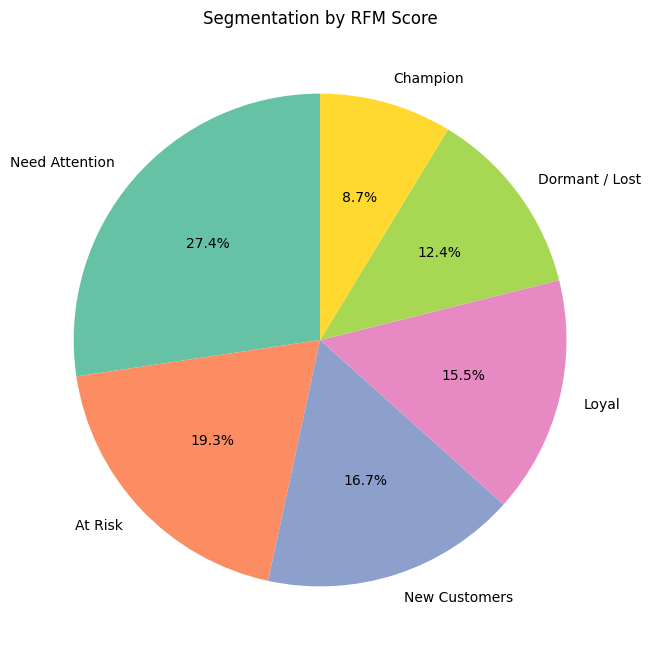

In [ ]:

# Hitung jumlah pelanggan di setiap segmen
segment_counts = summary['Segment'].value_counts()

# Membuat Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2', len(segment_counts)))
plt.title('Segmentation by RFM Score')
plt.show()